In [1]:
import os
import librosa
import numpy as np
from pathlib import Path
import warnings
import pandas as pd
from collections import Counter

warnings.filterwarnings('ignore')

# Set up paths
processed_folder = Path('./ml_data/resampled_16k')
print(f"Loading from: {processed_folder}")

Loading from: ml_data/resampled_16k


In [2]:
myVoices = []
failed_files = []

print("Loading audio dataset...")
print(f"Source: {processed_folder}\n")

for category_folder in sorted(processed_folder.iterdir()):
    if category_folder.is_dir():
        category = category_folder.name
        audio_files = list(category_folder.glob('*.wav'))
        
        print(f"Loading {category:20s}: {len(audio_files):4d} files", end=" ... ")
        
        success_count = 0
        for audio_path in audio_files:
            try:
                # Load audio with librosa (sr=None keeps original sample rate)
                waveform, sample_rate = librosa.load(str(audio_path), sr=None)
                myVoices.append({
                    'path': str(audio_path),
                    'filename': audio_path.name,
                    'waveform': waveform,
                    'sample_rate': sample_rate,
                    'category': category,
                    'duration': len(waveform) / sample_rate
                })
                success_count += 1
            except Exception as e:
                failed_files.append((category, audio_path.name, str(e)))
        
        print(f"✓ {success_count}")

print("✓ Audio loading complete!")

Loading audio dataset...
Source: ml_data/resampled_16k

Loading bike                :  508 files ... ✓ 508
Loading bus                 :  512 files ... ✓ 512
Loading car                 :  518 files ... ✓ 518
Loading cng_auto            :  508 files ... ✓ 508
Loading construction_noise  :  521 files ... ✓ 521
Loading protest             :  513 files ... ✓ 513
Loading siren               :  552 files ... ✓ 552
Loading traffic_jam         :  522 files ... ✓ 522
Loading train               :  500 files ... ✓ 500
Loading truck               :  517 files ... ✓ 517
✓ Audio loading complete!


In [3]:
print(f"\n{'='*60}")
print(f"DATASET SUMMARY")
print(f"{'='*60}")
print(f"Total files loaded: {len(myVoices)}")

if failed_files:
    print(f"Failed to load: {len(failed_files)} files")
    for cat, fname, error in failed_files[:5]:  # Show first 5 errors
        print(f"  - {cat}/{fname}: {error}")

# Show distribution
print(f"\nCategory Distribution:")
for cat, count in sorted(Counter([v['category'] for v in myVoices]).items()):
    print(f"  {cat:20s}: {count:3d} files")

# Show sample rate info
print(f"\nSample Rate Distribution:")
sample_rates = Counter([v['sample_rate'] for v in myVoices])
for sr, count in sorted(sample_rates.items()):
    print(f"  {sr:6d} Hz: {count:4d} files")

# Duration statistics
total_duration = sum(v['duration'] for v in myVoices)
avg_duration = total_duration / len(myVoices) if myVoices else 0
print(f"\nDuration Statistics:")
print(f"  Total: {total_duration/60:.2f} minutes")
print(f"  Average per file: {avg_duration:.2f} seconds")
print(f"{'='*60}")


DATASET SUMMARY
Total files loaded: 5171

Category Distribution:
  bike                : 508 files
  bus                 : 512 files
  car                 : 518 files
  cng_auto            : 508 files
  construction_noise  : 521 files
  protest             : 513 files
  siren               : 552 files
  traffic_jam         : 522 files
  train               : 500 files
  truck               : 517 files

Sample Rate Distribution:
   16000 Hz: 5171 files

Duration Statistics:
  Total: 861.83 minutes
  Average per file: 10.00 seconds


In [4]:
# Create a list to hold the data for the DataFrame
df_data = []

# Iterate through the myVoices list
for audio_item in myVoices:
    audio_path = audio_item['path']
    waveform = audio_item['waveform']
    sample_rate = audio_item['sample_rate']
    category = audio_item['category']

    df_data.append({
        'audio_path': audio_path,
        'waveform': waveform,
        'sample_rate': sample_rate,
        'category': category
    })

# Create the pandas DataFrame
myVoices_df = pd.DataFrame(df_data)

# Display the first few rows of the DataFrame
print("DataFrame Head:")
display(myVoices_df.head())

# Display the value counts for the 'category' column
print("\nCategory distribution:")
display(myVoices_df['category'].value_counts())

DataFrame Head:


,audio_path,waveform,sample_rate,category
0,ml_data/resampled_16k/bike/bike_0227.wav,"[0.03353882, 0.0736084, 0.07217407, 0.05239868...",16000,bike
1,ml_data/resampled_16k/bike/bike_0233.wav,"[-0.06161499, -0.11810303, -0.11727905, -0.134...",16000,bike
2,ml_data/resampled_16k/bike/bike_0019.wav,"[0.0340271, 0.059387207, 0.04849243, 0.0537414...",16000,bike
3,ml_data/resampled_16k/bike/bike_0025.wav,"[-0.009521484, -0.0074768066, 0.0018310547, 0....",16000,bike
4,ml_data/resampled_16k/bike/bike_0031.wav,"[0.053253174, 0.06774902, 0.025726318, 0.01165...",16000,bike



Category distribution:


category
siren                 552
traffic_jam           522
construction_noise    521
car                   518
truck                 517
protest               513
bus                   512
bike                  508
cng_auto              508
train                 500
Name: count, dtype: int64

In [5]:
if 'myVoices_df' in globals() and not myVoices_df.empty:
    # Find the minimum number of samples across all categories
    min_samples = myVoices_df['category'].value_counts().min()

    # Create an empty list to store the sampled dataframes
    balanced_df_list = []

    # Group by category and sample 'min_samples' from each group
    for category_name, group_df in myVoices_df.groupby('category'):
        # Use .sample() to randomly select 'min_samples' from the current category's dataframe
        sampled_group = group_df.sample(n=min_samples, random_state=42)
        balanced_df_list.append(sampled_group)

    # Concatenate the sampled dataframes back into a single dataframe
    balanced_myVoices_df = pd.concat(balanced_df_list).sample(frac=1, random_state=42).reset_index(drop=True)
    
    # Display the head and the new category distribution of the balanced DataFrame
    print("Balanced DataFrame Head:")
    display(balanced_myVoices_df.head())

    print("\nBalanced Category Distribution:")
    display(balanced_myVoices_df['category'].value_counts())

    print(f"\nOriginal number of samples: {len(myVoices_df)}")
    print(f"Number of samples in the balanced DataFrame: {len(balanced_myVoices_df)}")

else:
    print("The 'myVoices_df' DataFrame is not available or is empty.")

Balanced DataFrame Head:


,audio_path,waveform,sample_rate,category
0,ml_data/resampled_16k/cng_auto/cng_auto_0276.wav,"[0.14764404, 0.23196411, 0.18289185, 0.1997680...",16000,cng_auto
1,ml_data/resampled_16k/protest/protest_0457.wav,"[-3.0517578e-05, -3.0517578e-05, -3.0517578e-0...",16000,protest
2,ml_data/resampled_16k/protest/protest_0370.wav,"[0.09851074, 0.17684937, 0.169281, 0.16873169,...",16000,protest
3,ml_data/resampled_16k/car/car_0197.wav,"[0.0048217773, 0.0076904297, 0.0068969727, 0.0...",16000,car
4,ml_data/resampled_16k/bus/bus_0277.wav,"[-0.027252197, -0.033294678, -0.013793945, -0....",16000,bus



Balanced Category Distribution:


category
cng_auto              500
protest               500
car                   500
bus                   500
bike                  500
construction_noise    500
siren                 500
traffic_jam           500
truck                 500
train                 500
Name: count, dtype: int64


Original number of samples: 5171
Number of samples in the balanced DataFrame: 5000


In [6]:
# Calculate audio durations in seconds and extract sample rates
audio_durations = []
audio_sample_rates = []

for item in myVoices:
    waveform = item['waveform']
    sample_rate = item['sample_rate']

    # Duration = number of samples / sample rate
    duration = waveform.shape[-1] / sample_rate
    audio_durations.append(duration)
    audio_sample_rates.append(sample_rate)

print("Duration Statistics (first 10 files):")
print(f"Audio Durations (seconds): {audio_durations[:10]}")
print(f"Audio Sample Rates: {audio_sample_rates[:10]}")
print(f"\nMin duration: {min(audio_durations):.2f}s")
print(f"Max duration: {max(audio_durations):.2f}s")
print(f"Mean duration: {np.mean(audio_durations):.2f}s")

Duration Statistics (first 10 files):
Audio Durations (seconds): [10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0]
Audio Sample Rates: [16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000]

Min duration: 10.00s
Max duration: 10.00s
Mean duration: 10.00s


In [9]:
import torch
import torchaudio.transforms as T


In [10]:
def extract_mfcc_features(waveform, sample_rate, n_mfcc=40, n_fft=512, hop_length=160, max_padding=48000):
    """
    Extracts MFCC features from an audio waveform at 16kHz.
    """
    # Convert numpy array to torch tensor if needed
    if isinstance(waveform, np.ndarray):
        waveform = torch.from_numpy(waveform).float()
    
    # Ensure waveform is 2D: (channels, samples)
    if waveform.ndim == 1:
        waveform = waveform.unsqueeze(0)
    
    # Ensure waveform is mono if it has multiple channels
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)
    
    # ✅ Resample to 16kHz if needed
    target_sample_rate = 16000
    if sample_rate != target_sample_rate:
        resampler = T.Resample(sample_rate, target_sample_rate)
        waveform = resampler(waveform)
    
    # Pad or truncate the waveform to a fixed length
    if waveform.shape[-1] < max_padding:
        padding = max_padding - waveform.shape[-1]
        waveform = torch.nn.functional.pad(waveform, (0, padding))
    elif waveform.shape[-1] > max_padding:
        waveform = waveform[..., :max_padding]

    # Extract MFCC at 16kHz
    mfcc_transform = T.MFCC(
        sample_rate=16000,
        n_mfcc=n_mfcc,
        melkwargs={
            "n_fft": n_fft,
            "hop_length": hop_length,
            "n_mels": 128,
            "f_min": 0,
            "f_max": 8000,  # Nyquist frequency at 16kHz
        },
    )
    mfcc_features = mfcc_transform(waveform)
    return mfcc_features.squeeze(0)

print("✓ MFCC extraction function defined for 16kHz audio")


✓ MFCC extraction function defined for 16kHz audio


In [11]:
# List to store extracted features and labels
extracted_features = []

# Iterate through the myVoices list and extract features
print("Extracting MFCC features...")
for i, audio_item in enumerate(myVoices):
    try:
        waveform = audio_item['waveform']
        sample_rate = audio_item['sample_rate']
        category = audio_item['category']

        # Extract MFCC features
        features = extract_mfcc_features(waveform, sample_rate)

        # Append features and category to the list
        extracted_features.append({
            'features': features,
            'category': category
        })
        
        if (i + 1) % 100 == 0:
            print(f"  Processed {i + 1}/{len(myVoices)} files")
            
    except Exception as e:
        print(f"Could not extract features for {audio_item.get('path', 'an audio file')}: {e}")
        continue

print(f"✓ Feature extraction complete! Extracted {len(extracted_features)} features")

Extracting MFCC features...
  Processed 100/5171 files
  Processed 200/5171 files
  Processed 300/5171 files
  Processed 400/5171 files
  Processed 500/5171 files
  Processed 600/5171 files
  Processed 700/5171 files
  Processed 800/5171 files
  Processed 900/5171 files
  Processed 1000/5171 files
  Processed 1100/5171 files
  Processed 1200/5171 files
  Processed 1300/5171 files
  Processed 1400/5171 files
  Processed 1500/5171 files
  Processed 1600/5171 files
  Processed 1700/5171 files
  Processed 1800/5171 files
  Processed 1900/5171 files
  Processed 2000/5171 files
  Processed 2100/5171 files
  Processed 2200/5171 files
  Processed 2300/5171 files
  Processed 2400/5171 files
  Processed 2500/5171 files
  Processed 2600/5171 files
  Processed 2700/5171 files
  Processed 2800/5171 files
  Processed 2900/5171 files
  Processed 3000/5171 files
  Processed 3100/5171 files
  Processed 3200/5171 files
  Processed 3300/5171 files
  Processed 3400/5171 files
  Processed 3500/5171 files
 

In [7]:
# Create a DataFrame from the extracted features and labels
extracted_features_df = pd.DataFrame(extracted_features)

# Display the first few rows of the DataFrame and its shape
print("Extracted Features DataFrame:")
display(extracted_features_df.head())
print(f"\nShape of the extracted features DataFrame: {extracted_features_df.shape}")
print(f"Feature shape per sample: {extracted_features_df['features'].iloc[0].shape}")
print(f"\nCategory distribution:")
print(extracted_features_df['category'].value_counts())

NameError: name 'pd' is not defined

In [6]:
extracted_features_df_shuffled = extracted_features_df.sample(
    frac=1.0, 
    random_state=42
).reset_index(drop=True)


NameError: name 'extracted_features_df' is not defined

In [15]:
from sklearn.model_selection import train_test_split


In [16]:
# Extract features and labels
X = extracted_features_df_shuffled['features']
y = extracted_features_df_shuffled['category']

# Convert list of tensors to NumPy array
if all(item.shape == X.iloc[0].shape for item in X):
    X = torch.stack(list(X)).numpy()
else:
    raise ValueError("Feature tensor shapes are inconsistent, cannot stack.")

print(f"Stacked feature shape: {X.shape}")

# First split - Train vs Rest
X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"\n✓ First split done")
print(f"Train (raw): {len(X_train_raw)} samples")
print(f"Temp: {len(X_temp)} samples")

# Second split - Val vs Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.5, 
    random_state=42, 
    stratify=y_temp
)

print(f"\n✓ Second split done")
print(f"Validation: {len(X_val)} samples")
print(f"Test: {len(X_test)} samples")

Stacked feature shape: (5171, 40, 301)

✓ First split done
Train (raw): 4136 samples
Temp: 1035 samples

✓ Second split done
Validation: 517 samples
Test: 518 samples


In [17]:
print(f"Training set BEFORE balancing:")
print(pd.Series(y_train_raw).value_counts())

# Find minimum class count
class_counts = Counter(y_train_raw)
min_samples = min(class_counts.values())

# Undersample each class to min_samples
balanced_indices = []
for class_label in class_counts.keys():
    class_indices = np.where(y_train_raw == class_label)[0]
    sampled_indices = np.random.choice(
        class_indices, 
        size=min_samples, 
        replace=False
    )
    balanced_indices.extend(sampled_indices)

# Shuffle balanced indices
np.random.shuffle(balanced_indices)

# Create balanced training set
X_train = X_train_raw[balanced_indices]
y_train = y_train_raw.iloc[balanced_indices].reset_index(drop=True)

print(f"\nTraining set AFTER undersampling:")
print(pd.Series(y_train).value_counts())

# Final summary
print(f"\n{'='*60}")
print(f"FINAL DATASET SPLITS")
print(f"{'='*60}")
print(f"Training set:   {X_train.shape[0]} samples (BALANCED)")
print(f"Validation set: {X_val.shape[0]} samples (ORIGINAL)")
print(f"Test set:       {X_test.shape[0]} samples (ORIGINAL)")
print(f"{'='*60}")

Training set BEFORE balancing:
category
siren                 441
traffic_jam           418
construction_noise    417
truck                 414
car                   414
protest               410
bus                   410
cng_auto              406
bike                  406
train                 400
Name: count, dtype: int64

Training set AFTER undersampling:
category
cng_auto              400
bus                   400
train                 400
bike                  400
siren                 400
traffic_jam           400
construction_noise    400
car                   400
protest               400
truck                 400
Name: count, dtype: int64

FINAL DATASET SPLITS
Training set:   4000 samples (BALANCED)
Validation set: 517 samples (ORIGINAL)
Test set:       518 samples (ORIGINAL)


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("✓ Imports complete")

✓ Imports complete


In [19]:
class AudioCNN(nn.Module):
    def __init__(self, num_classes):
        super(AudioCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(3, 3), padding=(1, 1))
        self.relu = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3, 3), padding=(1, 1))
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(3, 3), padding=(1, 1))
        self.pool3 = nn.MaxPool2d(kernel_size=(2, 2), stride=(2, 2))

        # Calculate flattened size
        dummy_input = torch.randn(1, 1, X_train.shape[1], X_train.shape[2])
        dummy_output = self.pool3(self.relu(self.conv3(self.pool2(self.relu(self.conv2(self.pool1(self.relu(self.conv1(dummy_input)))))))))
        flattened_size = dummy_output.view(-1).shape[0]

        self.fc1 = nn.Linear(flattened_size, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

print("✓ CNN model defined")

✓ CNN model defined


In [10]:
num_classes = len(y_train.unique())

# Convert to tensors and add channel dimension
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)

# Encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

y_train_tensor = torch.tensor(y_train_encoded, dtype=torch.long)
y_val_tensor = torch.tensor(y_val_encoded, dtype=torch.long)
y_test_tensor = torch.tensor(y_test_encoded, dtype=torch.long)

# Create dataset and dataloader
class AudioDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

train_dataset = AudioDataset(X_train_tensor, y_train_tensor)
val_dataset = AudioDataset(X_val_tensor, y_val_tensor)
test_dataset = AudioDataset(X_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"✓ Data prepared")
print(f"  Train: {X_train_tensor.shape}")
print(f"  Val: {X_val_tensor.shape}")
print(f"  Test: {X_test_tensor.shape}")

NameError: name 'y_train' is not defined

In [21]:
train_accuracies = []


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = AudioCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20
train_losses = []
val_losses = []
train_accuracies = []  # Initialize empty list
val_accuracies = []

print("Starting CNN training...")
for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    correct_train = 0  # Reset for each epoch
    total_train = 0    # Reset for each epoch
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        running_loss += loss.item() * inputs.size(0)
    
    # Calculate epoch-level metrics
    epoch_loss = running_loss / len(train_dataset)
    epoch_train_accuracy = correct_train / total_train  # Calculate ONCE per epoch
    
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_train_accuracy)  # Append ONCE per epoch

    # Validation phase (no changes)
    model.eval()
    running_val_loss = 0.0
    correct_predictions = 0
    total_predictions = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_predictions += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_accuracy = correct_predictions / total_predictions
    
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f}, "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}")


Using device: cpu
Starting CNN training...
Epoch 5/20 - Train Loss: 0.4386, Train Acc: 0.8628, Val Loss: 0.3769, Val Acc: 0.8723
Epoch 10/20 - Train Loss: 0.2571, Train Acc: 0.9150, Val Loss: 0.3780, Val Acc: 0.9052
Epoch 15/20 - Train Loss: 0.1806, Train Acc: 0.9390, Val Loss: 0.3183, Val Acc: 0.9362
Epoch 20/20 - Train Loss: 0.1878, Train Acc: 0.9463, Val Loss: 0.3843, Val Acc: 0.9149


In [23]:
model.eval()
all_predictions = []
all_true_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_predictions.extend(predicted.tolist())
        all_true_labels.extend(labels.tolist())

# Calculate metrics
accuracy = accuracy_score(all_true_labels, all_predictions)
precision = precision_score(all_true_labels, all_predictions, average='weighted')
recall = recall_score(all_true_labels, all_predictions, average='weighted')
f1 = f1_score(all_true_labels, all_predictions, average='weighted')

cm = confusion_matrix(all_true_labels, all_predictions)
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

print("\n" + "="*60)
print("CNN Model Evaluation Metrics")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print("="*60)


CNN Model Evaluation Metrics
Accuracy:  0.8958
Precision: 0.8972
Recall:    0.8958
F1-score:  0.8934


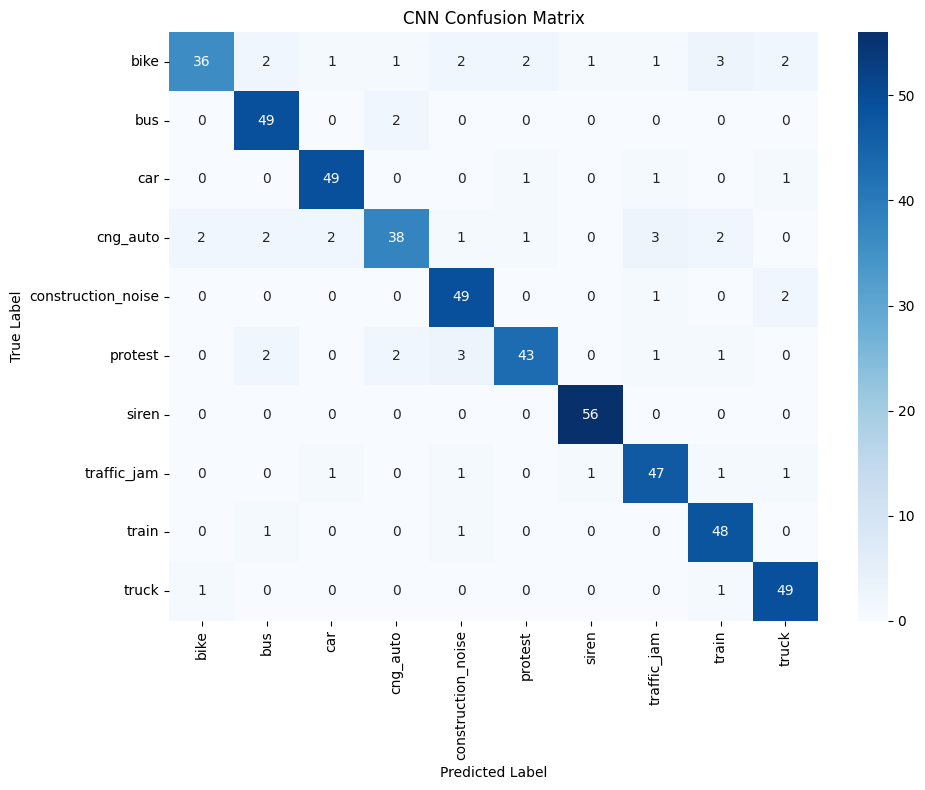

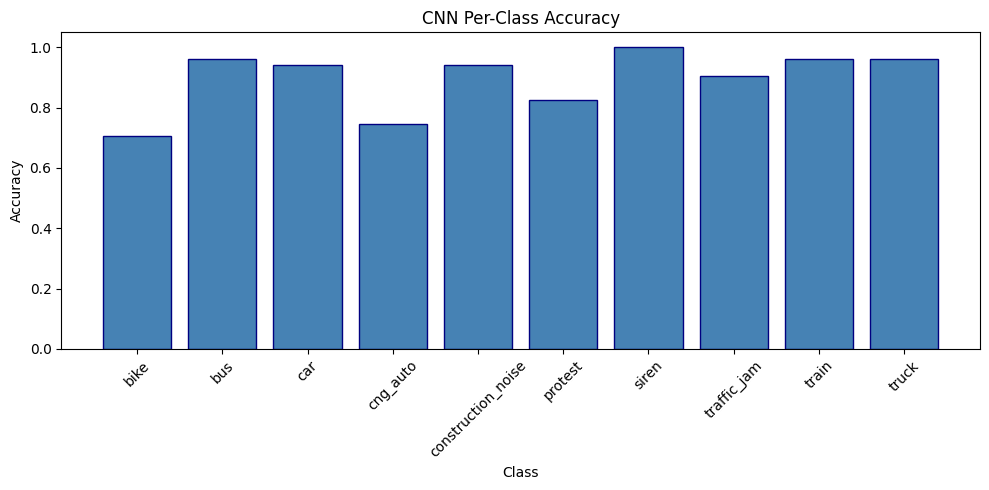

In [24]:
class_labels = label_encoder.classes_

# Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CNN Confusion Matrix')
plt.tight_layout()
plt.show()

# Per-class accuracy
plt.figure(figsize=(10, 5))
plt.bar(class_labels, per_class_accuracy, color='steelblue', edgecolor='navy')
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('CNN Per-Class Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

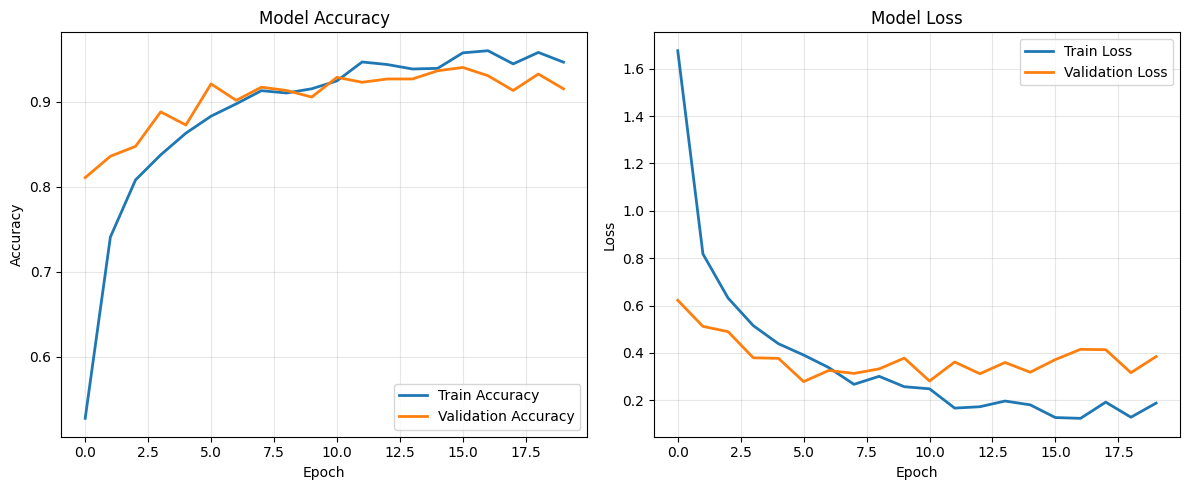

In [25]:
# After training loop completes
history = {
    'accuracy': train_accuracies,
    'val_accuracy': val_accuracies,
    'loss': train_losses,
    'val_loss': val_losses
}

def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Train Accuracy', linewidth=2)
    plt.plot(history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Train Loss', linewidth=2)
    plt.plot(history['val_loss'], label='Validation Loss', linewidth=2)
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [34]:
import pandas as pd
import torch
import torchaudio.transforms as T
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
# ═════════════════════════════════════════════════════════════════════════
# STEP 1: PREPARE AUDIO DATA FOR WAV2VEC2
# ═════════════════════════════════════════════════════════════════════════

TARGET_SAMPLE_RATE = 16000

print(f"Preparing audio data for Wav2Vec2 (resampling to {TARGET_SAMPLE_RATE}Hz and converting to mono-channel)...")

# Iterate through the myVoices list and prepare the audio data
for i, audio_item in enumerate(myVoices):
    waveform = audio_item['waveform']
    sample_rate = audio_item['sample_rate']

    # 1. Resample if necessary
    if sample_rate != TARGET_SAMPLE_RATE:
        resampler = T.Resample(orig_freq=sample_rate, new_freq=TARGET_SAMPLE_RATE)
        waveform = resampler(waveform)
        sample_rate = TARGET_SAMPLE_RATE  # Update sample rate

    # 2. Ensure mono-channel
    # Waveform shape is typically (channels, samples)
    if waveform.shape[0] > 1:
        waveform = torch.mean(waveform, dim=0, keepdim=True)  # Take mean across channels

    # Update the audio_item in myVoices
    myVoices[i]['waveform'] = waveform
    myVoices[i]['sample_rate'] = sample_rate

print("✓ Audio data preparation complete for Wav2Vec2.")

# Verify the first few processed items
print("\nVerifying sample rates and channel count for first 5 items:")
for i in range(min(5, len(myVoices))):
    item = myVoices[i]
    print(f"Item {i+1}: Sample Rate = {item['sample_rate']}Hz, Waveform Shape = {item['waveform'].shape}")

Preparing audio data for Wav2Vec2 (resampling to 16000Hz and converting to mono-channel)...
✓ Audio data preparation complete for Wav2Vec2.

Verifying sample rates and channel count for first 5 items:
Item 1: Sample Rate = 16000Hz, Waveform Shape = torch.Size([1, 160000])
Item 2: Sample Rate = 16000Hz, Waveform Shape = torch.Size([1, 160000])
Item 3: Sample Rate = 16000Hz, Waveform Shape = torch.Size([1, 160000])
Item 4: Sample Rate = 16000Hz, Waveform Shape = torch.Size([1, 160000])
Item 5: Sample Rate = 16000Hz, Waveform Shape = torch.Size([1, 160000])


In [37]:
# ═════════════════════════════════════════════════════════════════════════
# STEP 2: EXTRACT WAV2VEC2 FEATURES
# ═════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("STEP 2: EXTRACTING WAV2VEC2 FEATURES")
print("="*70)

# Ensure model and processor are on the correct device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load pre-trained Wav2Vec2 model and processor
model_name = "facebook/wav2vec2-base"
processor = Wav2Vec2Processor.from_pretrained(model_name)
model = Wav2Vec2Model.from_pretrained(model_name)

model.to(device)
model.eval()  # Set model to evaluation mode

# 1. Initialize an empty list to store the extracted features and corresponding categories
wav2vec2_features = []

print(f"\nExtracting Wav2Vec2 features using device: {device}...")

# 2. Iterate through each item in the myVoices list
for i, audio_item in enumerate(myVoices):
    waveform = audio_item['waveform']  # Waveform is already resampled to 16kHz and mono from previous step
    category = audio_item['category']

    try:
        # 3. Ensure the waveform is a PyTorch tensor and move it to the appropriate device
        # waveform is already a tensor (1, samples), we need to squeeze for the processor
        input_values = processor(
            waveform.squeeze(0), 
            return_tensors="pt", 
            sampling_rate=TARGET_SAMPLE_RATE
        ).input_values.to(device)

        # 4. Pass the processed input to the pre-trained model to obtain the hidden states
        with torch.no_grad():
            outputs = model(input_values)

        # 5. Take the mean of the last hidden state to represent the audio features
        # outputs.last_hidden_state has shape (batch_size, sequence_length, hidden_size)
        # We average along the sequence_length dimension to get a fixed-size feature vector
        features = outputs.last_hidden_state.mean(dim=1).squeeze(0)  # Remove batch dimension and get feature vector
        
        # 6. Convert to numpy and move to CPU to save GPU memory
        features = features.cpu().numpy()

        # 7. Store the extracted features and the category
        wav2vec2_features.append({
            'features': features,
            'category': category
        })
        
        if (i + 1) % 50 == 0:
            print(f"  Processed {i + 1}/{len(myVoices)} audio files")
            
    except Exception as e:
        print(f"Could not extract Wav2Vec2 features for item {i} (category: {category}): {e}")
        continue

print("✓ Wav2Vec2 feature extraction complete.")

# 8. Create a pandas DataFrame from the wav2vec2_features list
wav2vec2_features_df = pd.DataFrame(wav2vec2_features)

# 9. Display the first few rows of the wav2vec2_features_df and its shape
print(f"\nShape of the Wav2Vec2 features DataFrame: {wav2vec2_features_df.shape}")
print(f"Feature dimension: {wav2vec2_features_df['features'].iloc.shape}")
print(f"\nCategory distribution:")
print(wav2vec2_features_df['category'].value_counts())
print(f"\nFirst 5 rows:")
display(wav2vec2_features_df.head())



STEP 2: EXTRACTING WAV2VEC2 FEATURES
Using device: cpu

Extracting Wav2Vec2 features using device: cpu...
  Processed 50/5171 audio files
  Processed 100/5171 audio files
  Processed 150/5171 audio files
  Processed 200/5171 audio files
  Processed 250/5171 audio files
  Processed 300/5171 audio files
  Processed 350/5171 audio files
  Processed 400/5171 audio files
  Processed 450/5171 audio files
  Processed 500/5171 audio files
  Processed 550/5171 audio files
  Processed 600/5171 audio files
  Processed 650/5171 audio files
  Processed 700/5171 audio files
  Processed 750/5171 audio files
  Processed 800/5171 audio files
  Processed 850/5171 audio files
  Processed 900/5171 audio files
  Processed 950/5171 audio files
  Processed 1000/5171 audio files
  Processed 1050/5171 audio files
  Processed 1100/5171 audio files
  Processed 1150/5171 audio files
  Processed 1200/5171 audio files
  Processed 1250/5171 audio files
  Processed 1300/5171 audio files
  Processed 1350/5171 audio f

AttributeError: '_iLocIndexer' object has no attribute 'shape'

In [38]:
# ═════════════════════════════════════════════════════════════════════════
# STEP 3: PREPARE DATA FOR MODEL TRAINING
# ═════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("STEP 3: PREPARING DATA FOR MODEL TRAINING")
print("="*70 + "\n")

# Extract features and labels
import numpy as np
X = np.array([f for f in wav2vec2_features_df['features']])
y = wav2vec2_features_df['category'].values

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

print(f"Feature matrix shape: {X.shape}")
print(f"Number of classes: {num_classes}")
print(f"Class distribution: {label_encoder.classes_}\n")

# Split data into train/val/test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.4, random_state=42, stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Convert to tensors and add channel dimension for compatibility
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create dataset and dataloader
class AudioDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

train_dataset = AudioDataset(X_train_tensor, y_train_tensor)
val_dataset = AudioDataset(X_val_tensor, y_val_tensor)
test_dataset = AudioDataset(X_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"✓ Data prepared")
print(f"  Train: {X_train_tensor.shape}")
print(f"  Val: {X_val_tensor.shape}")
print(f"  Test: {X_test_tensor.shape}")



STEP 3: PREPARING DATA FOR MODEL TRAINING

Feature matrix shape: (5171, 768)
Number of classes: 10
Class distribution: ['bike' 'bus' 'car' 'cng_auto' 'construction_noise' 'protest' 'siren'
 'traffic_jam' 'train' 'truck']

✓ Data prepared
  Train: torch.Size([3102, 1, 768])
  Val: torch.Size([1034, 1, 768])
  Test: torch.Size([1035, 1, 768])


In [43]:
# ═════════════════════════════════════════════════════════════════════════
# STEP 4: DEFINE CLASSIFIER MODEL
# ═════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("STEP 4: DEFINING CLASSIFIER MODEL")
print("="*70 + "\n")

class AudioClassifier(nn.Module):
    def __init__(self, input_channels, num_classes):
        super(AudioClassifier, self).__init__()
        
        # Fully connected layers
        self.fc1 = nn.Linear(input_channels, 512)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.4)
        
        self.fc2 = nn.Linear(512, 256)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        
        self.fc3 = nn.Linear(256, 128)
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(0.2)
        
        self.fc4 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten
        
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)
        
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)
        
        x = self.fc3(x)
        x = self.relu3(x)
        x = self.dropout3(x)
        
        x = self.fc4(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

input_size = X_train_tensor.shape[1] * X_train_tensor.shape[2]
model = AudioClassifier(input_channels=input_size, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Model created on device: {device}")
print(f"Input channels: {X_train_tensor.shape * X_train_tensor.shape[2]}")
print(f"Number of classes: {num_classes}\n")



STEP 4: DEFINING CLASSIFIER MODEL

Using device: cpu
Model created on device: cpu
Input channels: torch.Size([3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1, 768, 3102, 1

In [44]:
# ═════════════════════════════════════════════════════════════════════════
# STEP 5: TRAIN MODEL
# ═════════════════════════════════════════════════════════════════════════

print("="*70)
print("STEP 5: TRAINING MODEL")
print("="*70 + "\n")

num_epochs = 20
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

print("Starting Wav2Vec2 classifier training...")
for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        running_loss += loss.item() * inputs.size(0)
    
    # Calculate epoch-level metrics
    epoch_loss = running_loss / len(train_dataset)
    epoch_train_accuracy = correct_train / total_train
    
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_train_accuracy)

    # Validation phase
    model.eval()
    running_val_loss = 0.0
    correct_predictions = 0
    total_predictions = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_predictions += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_accuracy = correct_predictions / total_predictions
    
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f}, "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f}")

print("✓ Training complete!\n")

STEP 5: TRAINING MODEL

Starting Wav2Vec2 classifier training...
Epoch 5/20 - Train Loss: 0.7122, Train Acc: 0.7434, Val Loss: 0.7135, Val Acc: 0.7369
Epoch 10/20 - Train Loss: 0.5106, Train Acc: 0.8246, Val Loss: 0.6122, Val Acc: 0.7921
Epoch 15/20 - Train Loss: 0.4138, Train Acc: 0.8588, Val Loss: 0.5602, Val Acc: 0.8095
Epoch 20/20 - Train Loss: 0.3260, Train Acc: 0.8852, Val Loss: 0.5110, Val Acc: 0.8414
✓ Training complete!



In [46]:
# ═════════════════════════════════════════════════════════════════════════
# STEP 6: EVALUATE ON TEST SET
# ═════════════════════════════════════════════════════════════════════════

print("="*70)
print("STEP 6: EVALUATING ON TEST SET")
print("="*70 + "\n")

model.eval()
all_predictions = []
all_true_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_predictions.extend(predicted.tolist())
        all_true_labels.extend(labels.tolist())

# Calculate metrics
accuracy = accuracy_score(all_true_labels, all_predictions)
precision = precision_score(all_true_labels, all_predictions, average='weighted')
recall = recall_score(all_true_labels, all_predictions, average='weighted')
f1 = f1_score(all_true_labels, all_predictions, average='weighted')

cm = confusion_matrix(all_true_labels, all_predictions)
per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

print("="*60)
print("Wav2Vec2 Model Evaluation Metrics")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print("="*60)

STEP 6: EVALUATING ON TEST SET

Wav2Vec2 Model Evaluation Metrics
Accuracy:  0.8396
Precision: 0.8431
Recall:    0.8396
F1-score:  0.8393



STEP 7: GENERATING VISUALIZATIONS



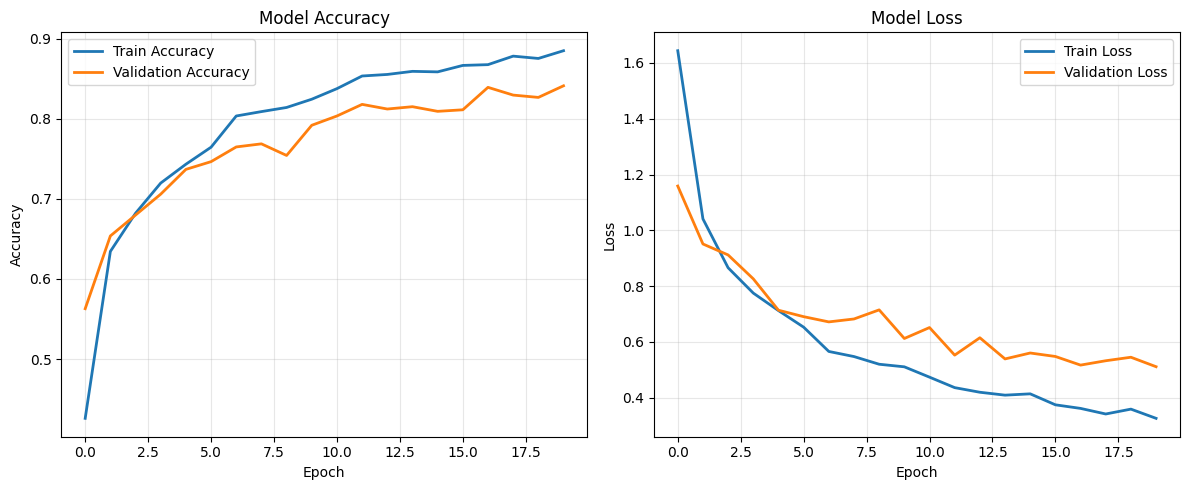

✓ Saved: wav2vec2_training_history.png


In [47]:
# ═════════════════════════════════════════════════════════════════════════
# STEP 7: PLOT TRAINING HISTORY
# ═════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("STEP 7: GENERATING VISUALIZATIONS")
print("="*70 + "\n")

# After training loop completes
history = {
    'accuracy': train_accuracies,
    'val_accuracy': val_accuracies,
    'loss': train_losses,
    'val_loss': val_losses
}

def plot_training_history(history):
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Train Accuracy', linewidth=2)
    plt.plot(history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Train Loss', linewidth=2)
    plt.plot(history['val_loss'], label='Validation Loss', linewidth=2)
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('wav2vec2_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history)
print("✓ Saved: wav2vec2_training_history.png")

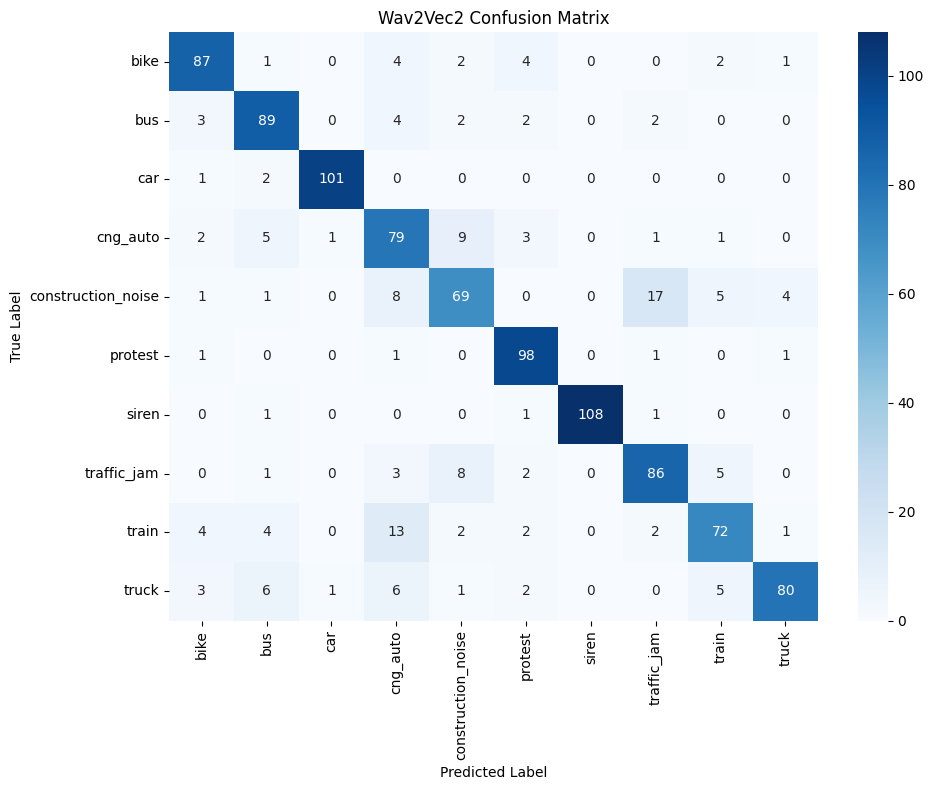

✓ Saved: wav2vec2_confusion_matrix.png


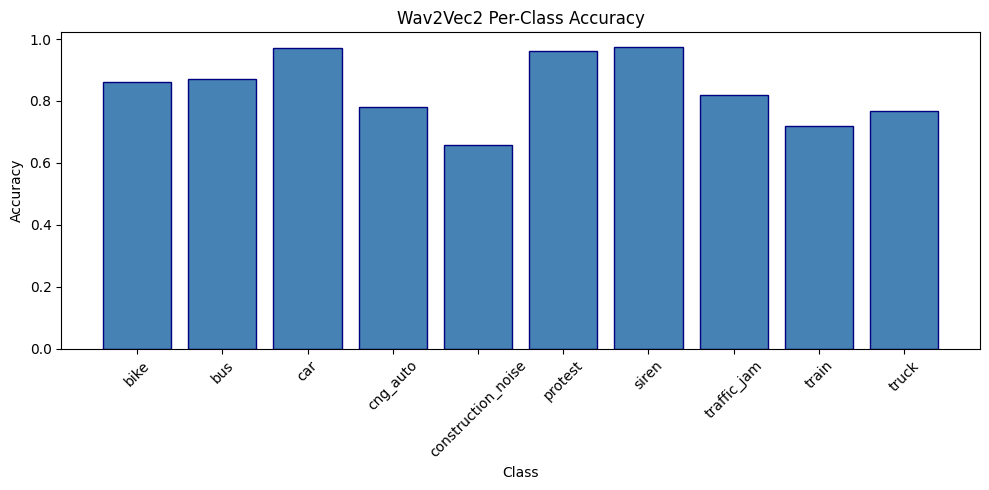

✓ Saved: wav2vec2_per_class_accuracy.png

✓ COMPLETE WAV2VEC2 PIPELINE FINISHED!

Generated files:
  1. wav2vec2_training_history.png
  2. wav2vec2_confusion_matrix.png
  3. wav2vec2_per_class_accuracy.png


In [48]:
# ═════════════════════════════════════════════════════════════════════════
# STEP 8: PLOT CONFUSION MATRIX
# ═════════════════════════════════════════════════════════════════════════

class_labels = label_encoder.classes_

# Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Wav2Vec2 Confusion Matrix')
plt.tight_layout()
plt.savefig('wav2vec2_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: wav2vec2_confusion_matrix.png")

# ═════════════════════════════════════════════════════════════════════════
# STEP 9: PLOT PER-CLASS ACCURACY
# ═════════════════════════════════════════════════════════════════════════

# Per-class accuracy
plt.figure(figsize=(10, 5))
plt.bar(class_labels, per_class_accuracy, color='steelblue', edgecolor='navy')
plt.xlabel('Class')
plt.ylabel('Accuracy')
plt.title('Wav2Vec2 Per-Class Accuracy')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('wav2vec2_per_class_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: wav2vec2_per_class_accuracy.png")

print("\n" + "="*70)
print("✓ COMPLETE WAV2VEC2 PIPELINE FINISHED!")
print("="*70)
print("\nGenerated files:")
print("  1. wav2vec2_training_history.png")
print("  2. wav2vec2_confusion_matrix.png")
print("  3. wav2vec2_per_class_accuracy.png")